In [1]:
import pandas as pd
import seaborn as sns
import pymongo
import os
from dotenv import load_dotenv  # Fixed ty
load_dotenv() 
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,average_precision_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore",category=UserWarning,module="sklearn")


In [2]:
df=pd.read_csv('/Users/anish/Desktop/Heart-Disease-Predictor/Notebooks/diabetes.csv',sep=';')


In [3]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [4]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


## Dataset Features

| Feature | Type | Column | Data Type / Values |
|---------|------|--------|--------------------|
| Age | Objective | `age` | Integer (days) |
| Height | Objective | `height` | Integer (cm) |
| Weight | Objective | `weight` | Float (kg) |
| Gender | Objective | `gender` | Categorical (1 = Female, 2 = Male) |
| Systolic Blood Pressure | Examination | `ap_hi` | Integer (mmHg) |
| Diastolic Blood Pressure | Examination | `ap_lo` | Integer (mmHg) |
| Cholesterol Level | Examination | `cholesterol` | 1 = Normal, 2 = Borderline High, 3 = High |
| Glucose Level | Examination | `gluc` | 1 = Normal, 2 = Borderline High, 3 = High |
| Smoking Status | Subjective | `smoke` | Binary (0 = No, 1 = Yes) |
| Alcohol Intake | Subjective | `alco` | Binary (0 = No, 1 = Yes) |
| Physical Activity | Subjective | `active` | Binary (0 = No, 1 = Yes) |
| Cardiovascular Disease | Target | `cardio` | Binary (0 = No Disease, 1 = Disease) |

In [6]:
df.isnull().sum()


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [7]:
df['ap_hi'].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [8]:
df['ap_hi'].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [9]:
df['ap_hi'].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [10]:
cardio_corr=df.corr()['cardio']

In [11]:
cardio_corr

id             0.003799
age            0.238159
gender         0.008109
height        -0.010821
weight         0.181660
ap_hi          0.054475
ap_lo          0.065719
cholesterol    0.221147
gluc           0.089307
smoke         -0.015486
alco          -0.007330
active        -0.035653
cardio         1.000000
Name: cardio, dtype: float64

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [13]:
print(df['height'].quantile(0.001))
print(df['height'].quantile(0.999))
print(df['weight'].quantile(0.001))
print(df['weight'].quantile(0.9999))


120.0
190.0
40.0
180.0


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [15]:
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42)

In [16]:
train_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
47339,67617,21876,1,154,80.0,130,90,2,1,0,0,1,1
67456,96320,16717,2,162,70.0,140,90,1,1,0,0,0,1
12308,17571,21128,2,174,92.0,150,100,1,1,0,0,1,1
32557,46492,23366,2,173,76.0,120,82,1,1,0,0,1,1
664,945,20281,1,160,60.0,120,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,53137,16001,2,170,75.0,150,80,1,1,1,0,1,1
6265,8918,23209,2,162,73.0,160,90,1,1,0,0,1,1
54886,78302,23589,1,169,74.0,120,80,1,1,0,0,1,0
860,1197,18227,1,167,70.0,120,80,1,1,0,0,0,0


In [17]:
train_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
47339,67617,21876,1,154,80.0,130,90,2,1,0,0,1,1
67456,96320,16717,2,162,70.0,140,90,1,1,0,0,0,1
12308,17571,21128,2,174,92.0,150,100,1,1,0,0,1,1
32557,46492,23366,2,173,76.0,120,82,1,1,0,0,1,1
664,945,20281,1,160,60.0,120,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,53137,16001,2,170,75.0,150,80,1,1,1,0,1,1
6265,8918,23209,2,162,73.0,160,90,1,1,0,0,1,1
54886,78302,23589,1,169,74.0,120,80,1,1,0,0,1,0
860,1197,18227,1,167,70.0,120,80,1,1,0,0,0,0


In [18]:
import pandas as pd

def data_cleaning(train_df, test_df):
    # 1. Calculate outlier thresholds strictly based on the training set

    low_ap_hi =  train_df['ap_hi'].quantile(0.001)
    high_ap_hi = train_df['ap_hi'].quantile(0.999)

    low_ap_lo = train_df['ap_lo'].quantile(0.001)
    high_ap_lo = train_df['ap_lo'].quantile(0.999)

    low_height = train_df['height'].quantile(0.001)
    high_height = train_df['height'].quantile(0.999)
    
    low_weight = train_df['weight'].quantile(0.001)
    high_weight = train_df['weight'].quantile(0.999)

    # List to hold our freshly processed dataframes
    cleaned_dfs = []

    # 2. Process each dataset
    for data_split in [train_df, test_df]:
        data_split = data_split.copy()
        
        data_split['age'] = (data_split['age'] / 365.0).astype(int)

        mask = (
            data_split['ap_hi'].between(low_ap_hi, high_ap_hi) &
            data_split['ap_lo'].between(low_ap_lo, high_ap_lo) &
            data_split['height'].between(low_height, high_height) &
            data_split['weight'].between(low_weight, high_weight)&
            (data_split['ap_hi']>data_split['ap_lo'])
        )

        # Filter the rows and reset the index (Saves the new object back to data_split)
        data_split = data_split[mask]
        
        # Save this fully cleaned dataframe to our list
        cleaned_dfs.append(data_split)

    # 3. Unpack and return outside the loop structure
    train_df, test_df = cleaned_dfs
    return train_df, test_df

In [19]:
train_df,test_df=data_cleaning(train_df,test_df)

In [20]:
train_df['ap_hi'].max()

np.int64(220)

In [21]:
train_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
47339,67617,59,1,154,80.0,130,90,2,1,0,0,1,1
67456,96320,45,2,162,70.0,140,90,1,1,0,0,0,1
12308,17571,57,2,174,92.0,150,100,1,1,0,0,1,1
32557,46492,64,2,173,76.0,120,82,1,1,0,0,1,1
664,945,55,1,160,60.0,120,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,53137,43,2,170,75.0,150,80,1,1,1,0,1,1
6265,8918,63,2,162,73.0,160,90,1,1,0,0,1,1
54886,78302,64,1,169,74.0,120,80,1,1,0,0,1,0
860,1197,49,1,167,70.0,120,80,1,1,0,0,0,0


In [22]:
metrics=pd.DataFrame()

In [23]:

def run_model(train_df,test_df,features,num_cols,cat_cols):
    
    num_pipeline=Pipeline(steps=[
    ("scaler",StandardScaler())])

    cat_pipeline=Pipeline(steps=[
        ("onehot",OneHotEncoder())])
    
    column_transformer=ColumnTransformer(
          transformers=[
            ("num_features",num_pipeline,num_cols),
            ("cat_features",cat_pipeline,cat_cols)
    ],
    remainder='passthrough'
          )
    preprocessor=Pipeline(steps=[
    ("column_transformer",column_transformer)
   ])
    x_train=train_df[features]
    y_train=train_df['cardio']

    x_test=test_df[features]
    y_test=test_df['cardio']

    # scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models = {
                # "Random Forest": RandomForestClassifier(verbose=1),
                # "Decision Tree": DecisionTreeClassifier(),
                # "Gradient Boosting": GradientBoostingClassifier(verbose=1),
                # # "Logistic Regression": LogisticRegression(verbose=1),
                # "AdaBoost": AdaBoostClassifier(),
                # # "Hist Gradient Boosting": HistGradientBoostingClassifier(),
                # "XGBoost": XGBClassifier(eval_metric='logloss'),
                # "LightGBM": LGBMClassifier(),
                "CatBoost":CatBoostClassifier(verbose=1)
    }

    for name,model in models.items():
    
     train_transform=preprocessor.fit_transform(x_train)
     test_transform=preprocessor.transform(x_test)

     model.fit(train_transform, y_train)
     probs = model.predict_proba(test_transform)[:, 1]

     roc_auc=roc_auc_score(y_test,probs)
     avg_precison = average_precision_score(y_test, probs)
     preds=np.where(probs>=0.5,1,0)

     results = test_df[['id']].copy()  
     results['prob']=preds
     results['actual']=y_test.values
     results['roc_auc']=roc_auc
     results['avg_precision']=avg_precison

     if len(cat_cols) > 0:
      ohe_feature_names = preprocessor.named_steps['column_transformer'] \
                                .named_transformers_['cat_features'] \
                                .get_feature_names_out(cat_cols).tolist()
     else:
       ohe_feature_names=[]
       
     all_feature_names = num_cols+ohe_feature_names

     importance = pd.DataFrame({
            'feature':    all_feature_names,
            'importance': model.feature_importances_
      }).sort_values('importance', ascending=False)
    
    return name,results,importance,model,preprocessor

In [24]:
def calculate_metrcis(name,metrics,test_desc:str,result:pd.DataFrame,roc_auc:float,average_precision:float)->pd.DataFrame:
  total=len(result)
  true_positive=np.sum((result['prob']==1)&(result['actual']==1))
  false_positive=np.sum((result['prob']==1)&(result['actual']==0))
  false_negative=np.sum((result['prob']==0)&(result['actual']==1))
  true_negative=np.sum((result['prob']==0)&( result['actual']==0))

  precision=true_positive/(true_positive+false_positive)
  recall=true_positive/(true_positive+false_negative)
  f1_score=(2*precision*recall)/(precision+recall)
  f2_score=(5*precision*recall)/(4*precision+recall)
  fraud_caught_pct=(true_positive/(true_positive+false_negative))*100
  fraud_missed=(false_negative/(true_positive+false_negative))*100
  flagged=((true_positive+false_positive)/total)*100

  new_series=pd.Series({
    'Model name':name,
    'ro-auc':round(roc_auc,2),
    'average_precision':round(average_precision,2),
    'precision':    round(precision, 4),
    'recall':       round(recall, 4),
    'f1_score':     round(f1_score, 4),
    'f2_score':     round(f2_score, 4),
    'Cardio Caught %': round(fraud_caught_pct, 2),
    'Cradio Missed %': round(fraud_missed, 2),
    'Flagged':      round(flagged, 2)
  }).rename(test_desc).to_frame()
  return pd.concat([metrics,new_series],axis=1)
  


In [25]:
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

features=num_cols+cat_cols

name,results,importance,model,preprocessor=run_model(train_df,test_df,features,num_cols,cat_cols)

metrics=calculate_metrcis(name,metrics,'baseline',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

Learning rate set to 0.056923
0:	learn: 0.6767186	total: 62.9ms	remaining: 1m 2s
1:	learn: 0.6622444	total: 66.9ms	remaining: 33.4s
2:	learn: 0.6493326	total: 70.1ms	remaining: 23.3s
3:	learn: 0.6380569	total: 73ms	remaining: 18.2s
4:	learn: 0.6277503	total: 76ms	remaining: 15.1s
5:	learn: 0.6189343	total: 79ms	remaining: 13.1s
6:	learn: 0.6107416	total: 82ms	remaining: 11.6s
7:	learn: 0.6035772	total: 85.1ms	remaining: 10.6s
8:	learn: 0.5972926	total: 88ms	remaining: 9.69s
9:	learn: 0.5918065	total: 91.2ms	remaining: 9.03s
10:	learn: 0.5869102	total: 94.2ms	remaining: 8.47s
11:	learn: 0.5828455	total: 96.9ms	remaining: 7.98s
12:	learn: 0.5788354	total: 99.7ms	remaining: 7.57s
13:	learn: 0.5752842	total: 103ms	remaining: 7.23s
14:	learn: 0.5720731	total: 105ms	remaining: 6.92s
15:	learn: 0.5690952	total: 108ms	remaining: 6.65s
16:	learn: 0.5666114	total: 111ms	remaining: 6.43s
17:	learn: 0.5645314	total: 114ms	remaining: 6.23s
18:	learn: 0.5624378	total: 117ms	remaining: 6.05s
19:	lear

In [26]:
metrics

,baseline
Model name,CatBoost
ro-auc,0.8
average_precision,0.78
precision,0.7552
recall,0.6962
f1_score,0.7245
f2_score,0.7073
Cardio Caught %,69.62
Cradio Missed %,30.38
Flagged,45.67


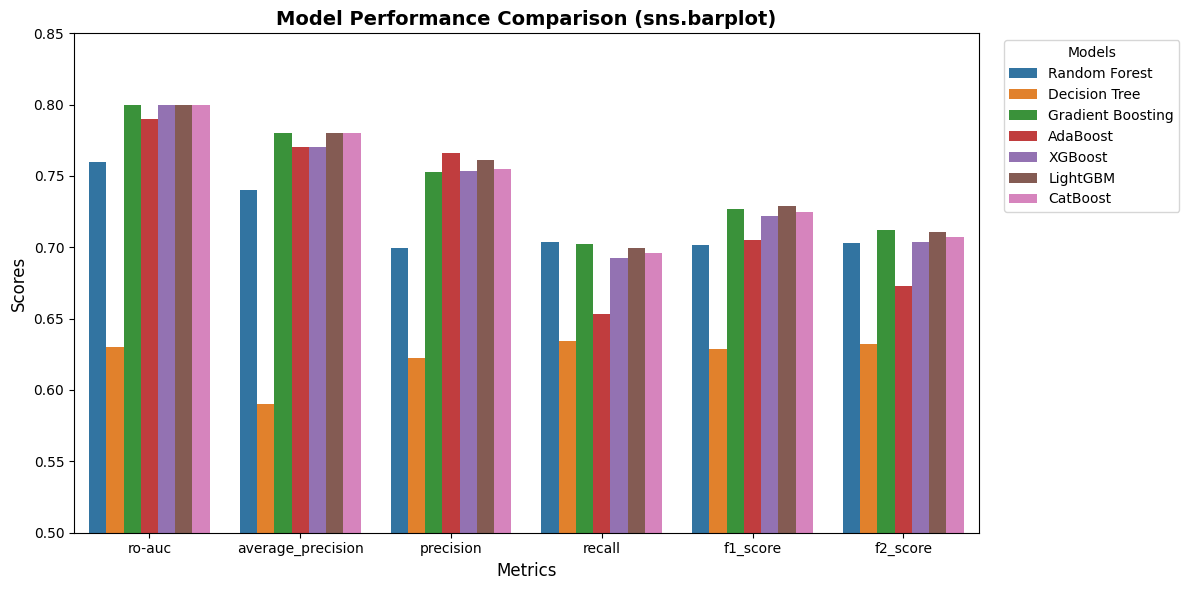

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Recreate your data
data = {
    "Metric": [
        "ro-auc",
        "average_precision",
        "precision",
        "recall",
        "f1_score",
        "f2_score",
    ],
    "Random Forest": [0.76, 0.74, 0.6996, 0.7039, 0.7018, 0.703],
    "Decision Tree": [0.63, 0.59, 0.6226, 0.6344, 0.6284, 0.632],
    "Gradient Boosting": [0.80, 0.78, 0.7527, 0.7024, 0.7267, 0.7119],
    "AdaBoost": [0.79, 0.77, 0.7660, 0.6531, 0.7051, 0.673],
    "XGBoost": [0.80, 0.77, 0.7537, 0.6925, 0.7218, 0.7039],
    "LightGBM": [0.80, 0.78, 0.7610, 0.6992, 0.7288, 0.7107],
    "CatBoost": [0.80, 0.78, 0.7552, 0.6962, 0.7245, 0.7073],
}

df = pd.DataFrame(data)

df_melted = df.melt(id_vars="Metric", var_name="Model", value_name="Score")

# 3. Initialize the plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", ax=ax)

# 5. Styling and formatting
ax.set_title(
    "Model Performance Comparison (sns.barplot)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Metrics", fontsize=12)
ax.set_ylabel("Scores", fontsize=12)

# Zooming in on the Y-axis to make the differences visible
ax.set_ylim(0.5, 0.85)

# Place the legend cleanly outside the plot area
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Models")
plt.tight_layout()

# Save or display the image
plt.savefig("sns_barplot_comparison.png", dpi=300)

<Figure size 1400x700 with 0 Axes>

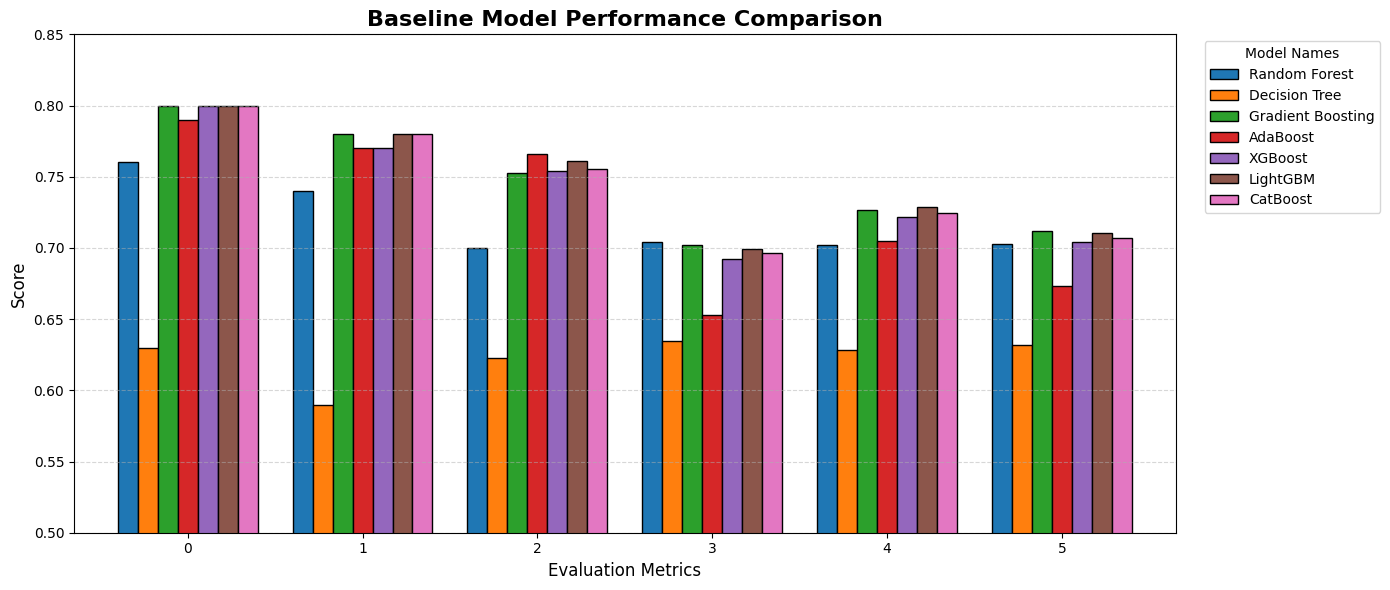

In [28]:
# Set up the plotting dimensions
plt.figure(figsize=(14, 7))

# Pandas built-in wrapper for matplotlib makes grouped bars incredibly simple
ax = df.plot(kind="bar", figsize=(14, 6), width=0.8, edgecolor="black")

plt.title("Baseline Model Performance Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=0)  # Keeps metric names perfectly horizontal
plt.ylim(0.5, 0.85)  # Zoomed in to clearly view differences between 0.6 and 0.8
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Model Names")

plt.tight_layout()
plt.show()

In [29]:
importance

,feature,importance
3,ap_hi,25.963820
0,age,19.523361
2,weight,14.497059
1,height,10.776184
4,ap_lo,7.301509
9,cholesterol_3,5.691329
7,cholesterol_1,3.012386
17,active_0,1.444567
18,active_1,1.442342
12,gluc_3,1.419362


In [30]:
train_df['age'].max()

np.int64(64)

In [31]:
def add_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df['_split'] = 'train'
    test_df['_split'] = 'test'
    
    df = pd.concat([train_df, test_df])

    df['bmi'] = df['weight'] / (df['height']/100)**2

    df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

    df['map'] = df['ap_lo'] + (df['ap_hi'] - df['ap_lo']) / 3
    
    df["Hypertension"] = (
    (df["ap_hi"] >= 140) |
    (df["ap_lo"] >= 90)
    ).astype(int)

    df["Age_Cholesterol"] = df["age"] * df["cholesterol"]
    df["Normal_BP"] = (
    (df["ap_hi"] < 120) &
    (df["ap_lo"] < 80)
     ).astype(int)

    df["High_Cholesterol"] = (df["cholesterol"] > 1).astype(int)

    df["High_Glucose"] = (df["gluc"] > 1).astype(int)


    bins = [29,40,50,60,70]
   
    labels = ['30-40','40-50','50-64','60+']
    df['age_bins'] = pd.cut(df['age'], bins=bins, labels=labels)

    bmi_bins = [0, 18.5, 25, 30, 35, 100]
    bmi_labels = ['underweight','normal','overweight','obese','severely_obese']
    df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels)

    df['unhealthy_life_style'] = df['smoke'] + df['alco'] + (1 - df['active'])

    train_df = df[df['_split'] == 'train'].drop(columns=['_split'])
    test_df = df[df['_split'] == 'test'].drop(columns=['_split'])

    return train_df, test_df

In [32]:
def bp_category(train_df,test_df):

    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df['_split'] = 'train'
    test_df['_split'] = 'test'
    df = pd.concat([train_df, test_df])

    conditions=[
        (df['ap_hi'] < 120)&(df['ap_lo'] < 80),
        (df['ap_hi'] < 130),
        (df['ap_hi'] < 140)
    ]
    choices=['normal', 'elevated', 'stage1']

    df['bp_category'] = np.select(conditions, choices, default='stage2')

    train_df = df[df['_split'] == 'train'].drop(columns=['_split'])
    test_df = df[df['_split'] == 'test'].drop(columns=['_split'])
    
    return train_df,test_df
    

In [33]:
train_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
47339,67617,59,1,154,80.0,130,90,2,1,0,0,1,1
67456,96320,45,2,162,70.0,140,90,1,1,0,0,0,1
12308,17571,57,2,174,92.0,150,100,1,1,0,0,1,1
32557,46492,64,2,173,76.0,120,82,1,1,0,0,1,1
664,945,55,1,160,60.0,120,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,53137,43,2,170,75.0,150,80,1,1,1,0,1,1
6265,8918,63,2,162,73.0,160,90,1,1,0,0,1,1
54886,78302,64,1,169,74.0,120,80,1,1,0,0,1,0
860,1197,49,1,167,70.0,120,80,1,1,0,0,0,0


In [34]:
train_df,test_df=add_features(train_df, test_df)
train_df,test_df=bp_category(train_df,test_df)

In [35]:
tuned_metrics=pd.DataFrame()

In [36]:

def run_tune_model(train_df,test_df,features,num_cols,cat_cols):
    
    num_pipeline=Pipeline(steps=[
    ("scaler",StandardScaler())])

    cat_pipeline=Pipeline(steps=[
        ("onehot",OneHotEncoder())])
    
    column_transformer=ColumnTransformer(
          transformers=[
            ("num_features",num_pipeline,num_cols),
            ("cat_features",cat_pipeline,cat_cols)
    ],
    remainder='passthrough'
          )
    preprocessor=Pipeline(steps=[
    ("column_transformer",column_transformer)
   ])
    x_train=train_df[features]
    y_train=train_df['cardio']

    x_test=test_df[features]
    y_test=test_df['cardio']

    # scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models = {
    # "Random Forest": RandomForestClassifier(
    #     n_estimators=300,
    #     max_depth=12,
    #     min_samples_split=5,
    #     min_samples_leaf=2,
    #     max_features="sqrt",
    #     random_state=42,
    #     n_jobs=-1,
    #     verbose=0,
    # ),
    # "Decision Tree": DecisionTreeClassifier(
    #     max_depth=8, min_samples_split=10, min_samples_leaf=4, random_state=42
    # ),
    # "Gradient Boosting": GradientBoostingClassifier(
    #     n_estimators=200,
    #     learning_rate=0.05,
    #     max_depth=5,
    #     subsample=0.8,
    #     min_samples_leaf=4,
    #     random_state=42,
    #     verbose=0,
    # ),
    # "AdaBoost": AdaBoostClassifier(
    #     estimator=DecisionTreeClassifier(max_depth=2),
    #     n_estimators=150,
    #     learning_rate=0.1,
    #     random_state=42,
    # ),
    # "XGBoost": XGBClassifier(
    #     n_estimators=300,
    #     learning_rate=0.05,
    #     max_depth=5,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     reg_alpha=0.1,  # L1 Regularization
    #     reg_lambda=1.0,  # L2 Regularization
    #     eval_metric="logloss",
    #     random_state=42,
    #     n_jobs=-1,
    # ),
    # "LightGBM": LGBMClassifier(
    #     n_estimators=300,
    #     learning_rate=0.05,
    #     max_depth=6,
    #     num_leaves=31,
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     reg_alpha=0.1,
    #     reg_lambda=1.0,
    #     random_state=42,
    #     n_jobs=-1,
    #     verbose=-1,  # Silences non-critical output
    # ),
    "CatBoost": CatBoostClassifier(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        bootstrap_type="Bernoulli",
        subsample=0.8,
        random_state=42,
        verbose=0,  # Set to 100 if you want to track training milestones
    ),
}

    for name,model in models.items():
    
     train_transform=preprocessor.fit_transform(x_train)
     test_transform=preprocessor.transform(x_test)

     model.fit(train_transform, y_train)
     probs = model.predict_proba(test_transform)[:, 1]

     roc_auc=roc_auc_score(y_test,probs)
     avg_precison = average_precision_score(y_test, probs)
     preds=np.where(probs>=0.5,1,0)

     results = test_df[['id']].copy()  
     results['prob']=preds
     results['actual']=y_test.values
     results['roc_auc']=roc_auc
     results['avg_precision']=avg_precison

     if len(cat_cols) > 0:
      ohe_feature_names = preprocessor.named_steps['column_transformer'] \
                                .named_transformers_['cat_features'] \
                                .get_feature_names_out(cat_cols).tolist()
     else:
       ohe_feature_names=[]
       
     all_feature_names = num_cols+ohe_feature_names

     importance = pd.DataFrame({
            'feature':    all_feature_names,
            'importance': model.feature_importances_
      }).sort_values('importance', ascending=False)
    
    return name,results,importance,model,preprocessor

In [37]:
def calculate_metrcis(name,metrics,test_desc:str,result:pd.DataFrame,roc_auc:float,average_precision:float)->pd.DataFrame:
  total=len(result)
  true_positive=np.sum((result['prob']==1)&(result['actual']==1))
  false_positive=np.sum((result['prob']==1)&(result['actual']==0))
  false_negative=np.sum((result['prob']==0)&(result['actual']==1))
  true_negative=np.sum((result['prob']==0)&( result['actual']==0))

  precision=true_positive/(true_positive+false_positive)
  recall=true_positive/(true_positive+false_negative)
  f1_score=(2*precision*recall)/(precision+recall)
  f2_score=(5*precision*recall)/(4*precision+recall)
  fraud_caught_pct=(true_positive/(true_positive+false_negative))*100
  fraud_missed=(false_negative/(true_positive+false_negative))*100
  flagged=((true_positive+false_positive)/total)*100

  new_series=pd.Series({
    'Model name':name,
    'ro-auc':round(roc_auc,2),
    'average_precision':round(average_precision,2),
    'precision':    round(precision, 4),
    'recall':       round(recall, 4),
    'f1_score':     round(f1_score, 4),
    'f2_score':     round(f2_score, 4),
    'Cardio Caught %': round(fraud_caught_pct, 2),
    'Cradio Missed %': round(fraud_missed, 2),
    'Flagged':      round(flagged, 2)
  }).rename(test_desc).to_frame()
  return pd.concat([metrics,new_series],axis=1)
  


In [38]:
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo','bmi','pulse_pressure','map']
cat_cols = ['bmi_category','bp_category','gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active','unhealthy_life_style','Normal_BP',
       'High_Cholesterol', 'High_Glucose']
 # correct if truly no non-ordinal multi-level columns

features=num_cols+cat_cols
name,results,importance,model,preprocessor=run_tune_model(train_df,test_df,features,num_cols,cat_cols)
tuned_metrics=calculate_metrcis(name,tuned_metrics,'Feature Tuning',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

In [39]:
tuned_metrics

,Feature Tuning
Model name,CatBoost
ro-auc,0.8
average_precision,0.78
precision,0.7539
recall,0.6999
f1_score,0.7259
f2_score,0.7101
Cardio Caught %,69.99
Cradio Missed %,30.01
Flagged,46.0


In [40]:
hyper_tuned_metrics2=pd.DataFrame()

In [41]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


def run_tune_model(train_df, test_df, features, num_cols, cat_cols):

    num_pipeline = Pipeline(steps=[("scaler", StandardScaler())])

    cat_pipeline = Pipeline(steps=[("onehot", OneHotEncoder())])

    column_transformer = ColumnTransformer(
        transformers=[
            ("num_features", num_pipeline, num_cols),
            ("cat_features", cat_pipeline, cat_cols),
        ],
        remainder="passthrough",
    )

    preprocessor = Pipeline(
        steps=[("column_transformer", column_transformer)]
    )

    x_train = train_df[features]
    y_train = train_df["cardio"]

    x_test = test_df[features]
    y_test = test_df["cardio"]

    # scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models = {
        # "Decision Tree": DecisionTreeClassifier()
        # "Random Forest": RandomForestClassifier(),
        # "Gradient Boosting": GradientBoostingClassifier(),
        # "AdaBoost": AdaBoostClassifier(),
        # "Logistic Regression":LogisticRegressor()
        "XGBoost": XGBClassifier(),
        # "LightGBM": LGBMClassifier(),
        # "CatBoost": CatBoostClassifier(),
    }

    param_distributions = {
        # "Decision Tree": {
        #     "max_depth": [3, 4, 5],  # allowed a definite depth such that model doesn't memeorize till infinite depth
        #     "criterion": ["gini", "entropy"],  # criterion for creating a tree
        #     "min_samples_split": [5, 10, 20],  # min samples requried to split a tree
        #     "min_samples_leaf": [5, 10, 20],  # min samples required or left on leaf to split
        #     "splitter": ["best", "random"],  # best parameters selection or random parameter selection
        #     "max_features": ["sqrt", 2, 4],  # how many features selectres based on sqrt(n) OR LOG(n) where N is the no of columns in a database
        # },
        # "Random Forest":{
        #     'criterion': ['gini', 'entropy'],  # criterion for creating a tree
        #     'max_depth':[4,6,8,10],        # allowed a definite depth such that model doesn't memeorize till infinite depth
        #     'min_samples_split':[5,10,20],   # min samples requried to split a tree
        #     'min_samples_leaf':[5,10,20],    # min samples required or left on leaf to split
        #     'max_features':['sqrt',2,4],  # how many features selectres based on sqrt(n) OR LOG(n) where N is the no of columns in a database
        #     'n_estimators': [200, 300], # independent tress to create for judgement
        # },
        # "Gradient Boosting":{
        #     'loss':['log_loss', 'exponential'],
        #     'learning_rate':[.05,.01],
        #     'subsample':[0.7,0.8],
        #     'criterion':['squared_error', 'friedman_mse'],
        #     'n_estimators': [50, 100, 200, 300],             # independent tress to create for judgement
        #     'max_depth':[3,4,5],
        # },
        # "AdaBoost": {
        #    'learning_rate': [0.1, 0.05, 0.01],
        #    'n_estimators': [50, 100, 200,300],                    # Low estimators make AdaBoost underperform
        # },
        # "Logistic Regression": {
        # 'penalty': ['l2'],                                 # Regularization type
        # 'C': [0.01, 0.1, 1.0, 10.0],                       # Inverse regularization strength (smaller = less overfitting)
        # 'solver': ['lbfgs', 'saga'],                       # Optimization algorithms
        # 'max_iter': [100, 500]                             # Gives the solver enough time to converge
        # "Hist Gradient Boosting": {
        #     'learning_rate': [0.01, 0.05, 0.1],
        #     'max_iter': [100, 200],
        #     'max_depth': [3, 5, 7]
        # },
        "XGBoost": {
            'learning_rate': [0.03, 0.05, 0.1],          # Shifting away from 0.01 (often too slow for tabular depth)
            'n_estimators': [300,500,1000],             # Added 300 to match lower learning rates
            'max_depth': [3, 5, 6],                      # 7 can overfit tabular data easily; 6 is often the sweet spot
            'subsample': [0.8, 0.9],                     # Added 0.9 for slight variance changes
            'colsample_bytree': [0.8, 1.0],              # CRUCIAL: Fraction of features evaluated per tree (prevents dominant features from taking over)
            'gamma': [0, 0.1, 0.2]                       # Minimum loss reduction required to make a split (adds structural pruning)
        }
    #     "LightGBM": {
    #     "n_estimators": [500, 1000, 1500],
    #      "num_leaves": [12,15,18],
    #      "learning_rate": [0.01, 0.05, 0.1],
    #      "max_depth": [-1, 6, 8],
    #       "reg_alpha": [0.0, 0.1, 1.0, 10.0],    
    #      "reg_lambda": [0.0, 0.1, 1.0, 10.0],
    #  }
#        "CatBoost": {
#           "depth": [4, 6, 8],
#           "learning_rate": [0.01, 0.03, 0.05],
#           "iterations": [300, 500, 800,1000],
#           "l2_leaf_reg": [1, 3, 5, 7],
#           "border_count": [32, 64, 128],
# }

        # "Hist Gradient Boosting": {
        #     'learning_rate': [0.01, 0.05, 0.1],
        #     'max_iter': [100, 200, 300],
        #     'max_leaf_nodes': [15, 31, 63],
        #     'min_samples_leaf': [20, 50, 100]
        # }
    }

    for name, model in models.items():

        train_transform = preprocessor.fit_transform(x_train)
        test_transform = preprocessor.transform(x_test)

        randomsearch = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_distributions[name],
            # verbose=2,
            n_jobs=-1,
            cv=3,
        )
        randomsearch.fit(train_transform, y_train)

        # Note: Using the fitted search object to make predictions
        probs = randomsearch.predict_proba(test_transform)[:, 1]

        roc_auc = roc_auc_score(y_test, probs)
        avg_precison = average_precision_score(y_test, probs)
        preds = np.where(probs >= 0.5, 1, 0)

        results = test_df[["id"]].copy()
        results["prob"] = preds
        results["actual"] = y_test.values
        results["roc_auc"] = roc_auc
        results["avg_precision"] = avg_precison

        if len(cat_cols) > 0:
            ohe_feature_names = (
                preprocessor.named_steps["column_transformer"]
                .named_transformers_["cat_features"]
                .get_feature_names_out(cat_cols)
                .tolist()
            )
        else:
            ohe_feature_names = []

        all_feature_names = num_cols + ohe_feature_names

        importance = pd.DataFrame(
            {
                "feature": all_feature_names,
                "importance": randomsearch.best_estimator_.feature_importances_,
            }
        ).sort_values("importance", ascending=False)

    return name, results, importance, randomsearch.best_estimator_, preprocessor

In [42]:
def calculate_metrcis(name,metrics,test_desc:str,result:pd.DataFrame,roc_auc:float,average_precision:float)->pd.DataFrame:
  total=len(result)
  true_positive=np.sum((result['prob']==1)&(result['actual']==1))
  false_positive=np.sum((result['prob']==1)&(result['actual']==0))
  false_negative=np.sum((result['prob']==0)&(result['actual']==1))
  true_negative=np.sum((result['prob']==0)&( result['actual']==0))

  precision=true_positive/(true_positive+false_positive)
  recall=true_positive/(true_positive+false_negative)
  f1_score=(2*precision*recall)/(precision+recall)
  f2_score=(5*precision*recall)/(4*precision+recall)
  fraud_caught_pct=(true_positive/(true_positive+false_negative))*100
  fraud_missed=(false_negative/(true_positive+false_negative))*100
  flagged=((true_positive+false_positive)/total)*100

  new_series=pd.Series({
    'Model name':name,
    'ro-auc':round(roc_auc,2),
    'average_precision':round(average_precision,2),
    'precision':    round(precision, 4),
    'recall':       round(recall, 4),
    'f1_score':     round(f1_score, 4),
    'f2_score':     round(f2_score, 4),
    'Cardio Caught %': round(fraud_caught_pct, 2),
    'Cradio Missed %': round(fraud_missed, 2),
    'Flagged':      round(flagged, 2)
  }).rename(test_desc).to_frame()
  return pd.concat([metrics,new_series],axis=1)
  


In [43]:
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo','bmi','pulse_pressure','map']
cat_cols = ['bmi_category','bp_category','gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active','unhealthy_life_style','Normal_BP',
       'High_Cholesterol', 'High_Glucose']
 # correct if truly no non-ordinal multi-level columns

features=num_cols+cat_cols
name,results,importance,model,preprocessor=run_tune_model(train_df,test_df,features,num_cols,cat_cols)
hyper_tuned_metrics2=calculate_metrcis(name,hyper_tuned_metrics2,'Feature Tuning',results,results['roc_auc'].iloc[0],results['avg_precision'].iloc[0])

In [44]:
hyper_tuned_metrics2

,Feature Tuning
Model name,XGBoost
ro-auc,0.8
average_precision,0.78
precision,0.7581
recall,0.6992
f1_score,0.7274
f2_score,0.7102
Cardio Caught %,69.92
Cradio Missed %,30.08
Flagged,45.7


In [45]:
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

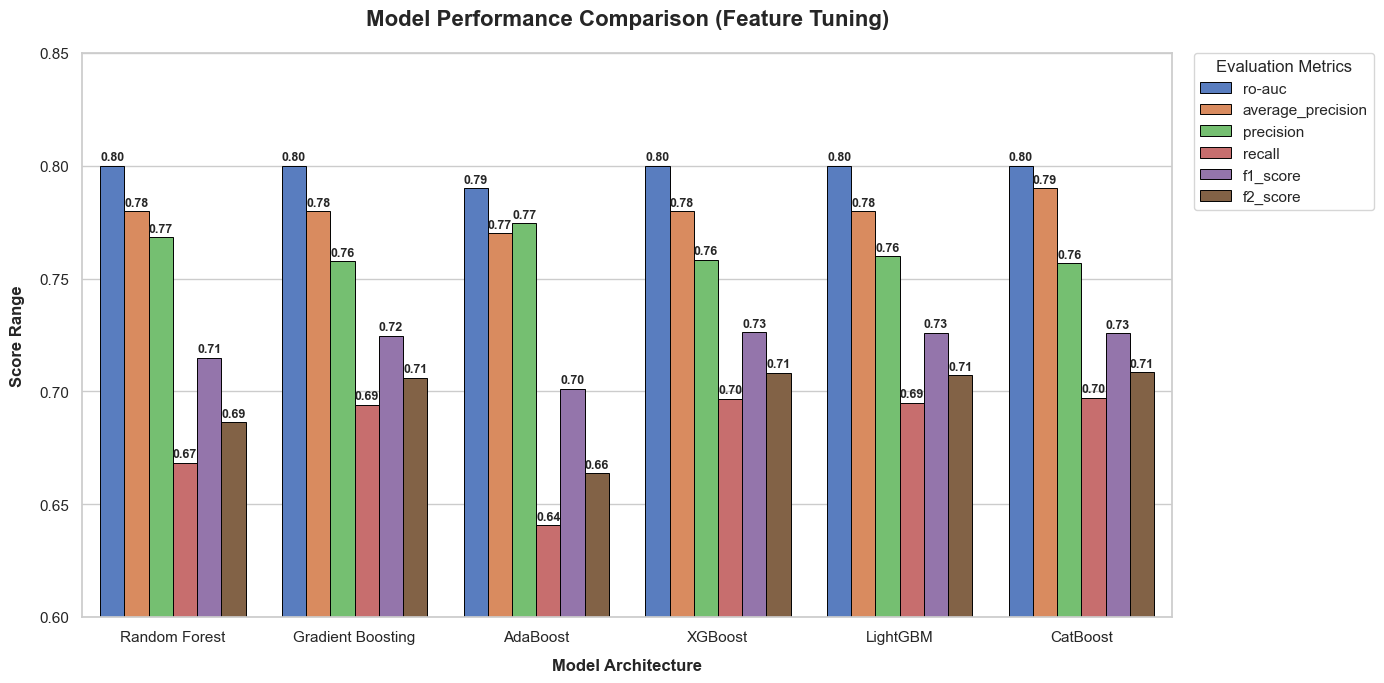

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Recreate your dataset from the image
data = {
    "Model name": [
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost",
        "XGBoost",
        "LightGBM",
        "CatBoost",
    ],
    "ro-auc": [0.80, 0.80, 0.79, 0.80, 0.80, 0.80],
    "average_precision": [0.78, 0.78, 0.77, 0.78, 0.78, 0.79],
    "precision": [0.7684, 0.7578, 0.7745, 0.7584, 0.7599, 0.7567],
    "recall": [0.6683, 0.6941, 0.6406, 0.6967, 0.6950, 0.6972],
    "f1_score": [0.7149, 0.7246, 0.7012, 0.7262, 0.7260, 0.7258],
    "f2_score": [0.6862, 0.7060, 0.6636, 0.7082, 0.7071, 0.7084],
}

df = pd.DataFrame(data)

# 2. Melt dataframe for Seaborn grouped plotting
# This transforms columns into rows so Seaborn can group them easily
metrics_to_plot = [
    "ro-auc",
    "average_precision",
    "precision",
    "recall",
    "f1_score",
    "f2_score",
]
df_melted = pd.melt(
    df,
    id_vars="Model name",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score",
)

# 3. Initialize the plot style and size
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 4. Create the grouped bar chart
ax = sns.barplot(
    data=df_melted,
    x="Model name",
    y="Score",
    hue="Metric",
    palette="muted",
    edgecolor="black",
    linewidth=0.7,
)

# 5. Fine-tune visuals for readability
plt.title(
    "Model Performance Comparison (Feature Tuning)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Model Architecture", fontsize=12, fontweight="semibold", labelpad=10)
plt.ylabel("Score Range", fontsize=12, fontweight="semibold", labelpad=10)

# Set y-axis bounds to clearly see the differences since values range from 0.64 to 0.80
plt.ylim(0.60, 0.85)

# Place the legend cleanly outside the main plot area
plt.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=True,
)

# 6. Annotate the exact values on top of the bars (Optional but highly useful)
for p in ax.patches:
    if p.get_height() > 0:  # Skip empty patches if any
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 6),
            textcoords="offset points",
            fontsize=9,
            fontweight="semibold",
        )

plt.tight_layout()

# 7. Save the figure in high definition (300 DPI)
plt.savefig("model_comparison_metrics.png", dpi=300, bbox_inches="tight")

# 8. Render the plot to the screen
plt.show()

In [47]:
train_df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,...,map,Hypertension,Age_Cholesterol,Normal_BP,High_Cholesterol,High_Glucose,age_bins,bmi_category,unhealthy_life_style,bp_category
47339,67617,59,1,154,80.0,130,90,2,1,0,...,103.333333,1,118,0,1,0,50-64,obese,0,stage1
67456,96320,45,2,162,70.0,140,90,1,1,0,...,106.666667,1,45,0,0,0,40-50,overweight,1,stage2
12308,17571,57,2,174,92.0,150,100,1,1,0,...,116.666667,1,57,0,0,0,50-64,obese,0,stage2
32557,46492,64,2,173,76.0,120,82,1,1,0,...,94.666667,0,64,0,0,0,60+,overweight,0,elevated
664,945,55,1,160,60.0,120,80,1,1,0,...,93.333333,0,55,0,0,0,50-64,normal,0,elevated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,53137,43,2,170,75.0,150,80,1,1,1,...,103.333333,1,43,0,0,0,40-50,overweight,1,stage2
6265,8918,63,2,162,73.0,160,90,1,1,0,...,113.333333,1,63,0,0,0,60+,overweight,0,stage2
54886,78302,64,1,169,74.0,120,80,1,1,0,...,93.333333,0,64,0,0,0,60+,overweight,0,elevated
860,1197,49,1,167,70.0,120,80,1,1,0,...,93.333333,0,49,0,0,0,40-50,overweight,1,elevated


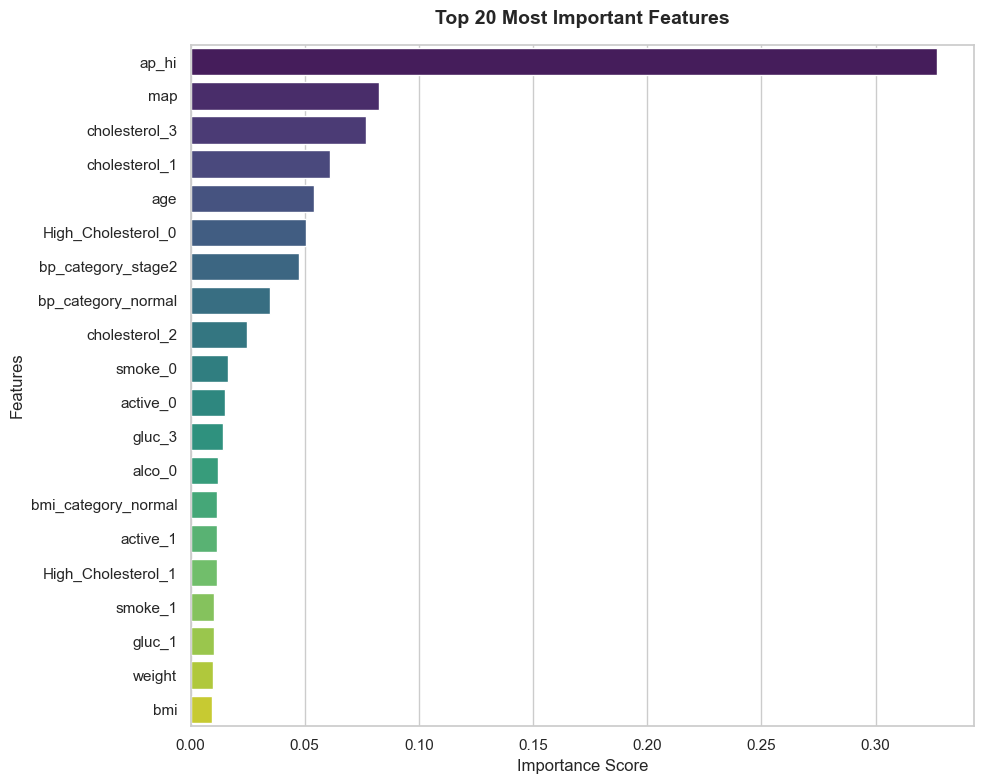

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = importance.head(20)

plt.figure(figsize=(10, 8))

# 3. Plot with a clean color palette
sns.barplot(
    data=importance,
    x="importance",
    y="feature",
    palette="viridis",    # Gives a smooth, professional color gradient
    hue="feature",        # Keeps seaborn happy with clean color mapping
    legend=False
)

# 4. Add clear labels and title
plt.title('Top 20 Most Important Features', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 5. Clean layout and display
plt.tight_layout()
plt.show()

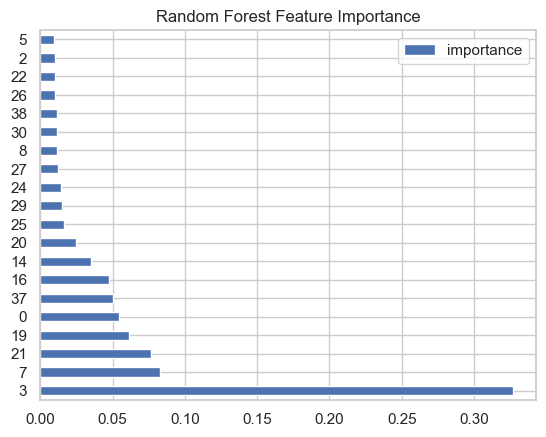

In [49]:
importance.head(20)
importance.plot(kind="barh")

plt.title("Random Forest Feature Importance")

plt.show()

In [50]:
train_df['ap_hi'].max()

np.int64(220)

In [51]:
features

['age',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'bmi',
 'pulse_pressure',
 'map',
 'bmi_category',
 'bp_category',
 'gender',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'unhealthy_life_style',
 'Normal_BP',
 'High_Cholesterol',
 'High_Glucose']

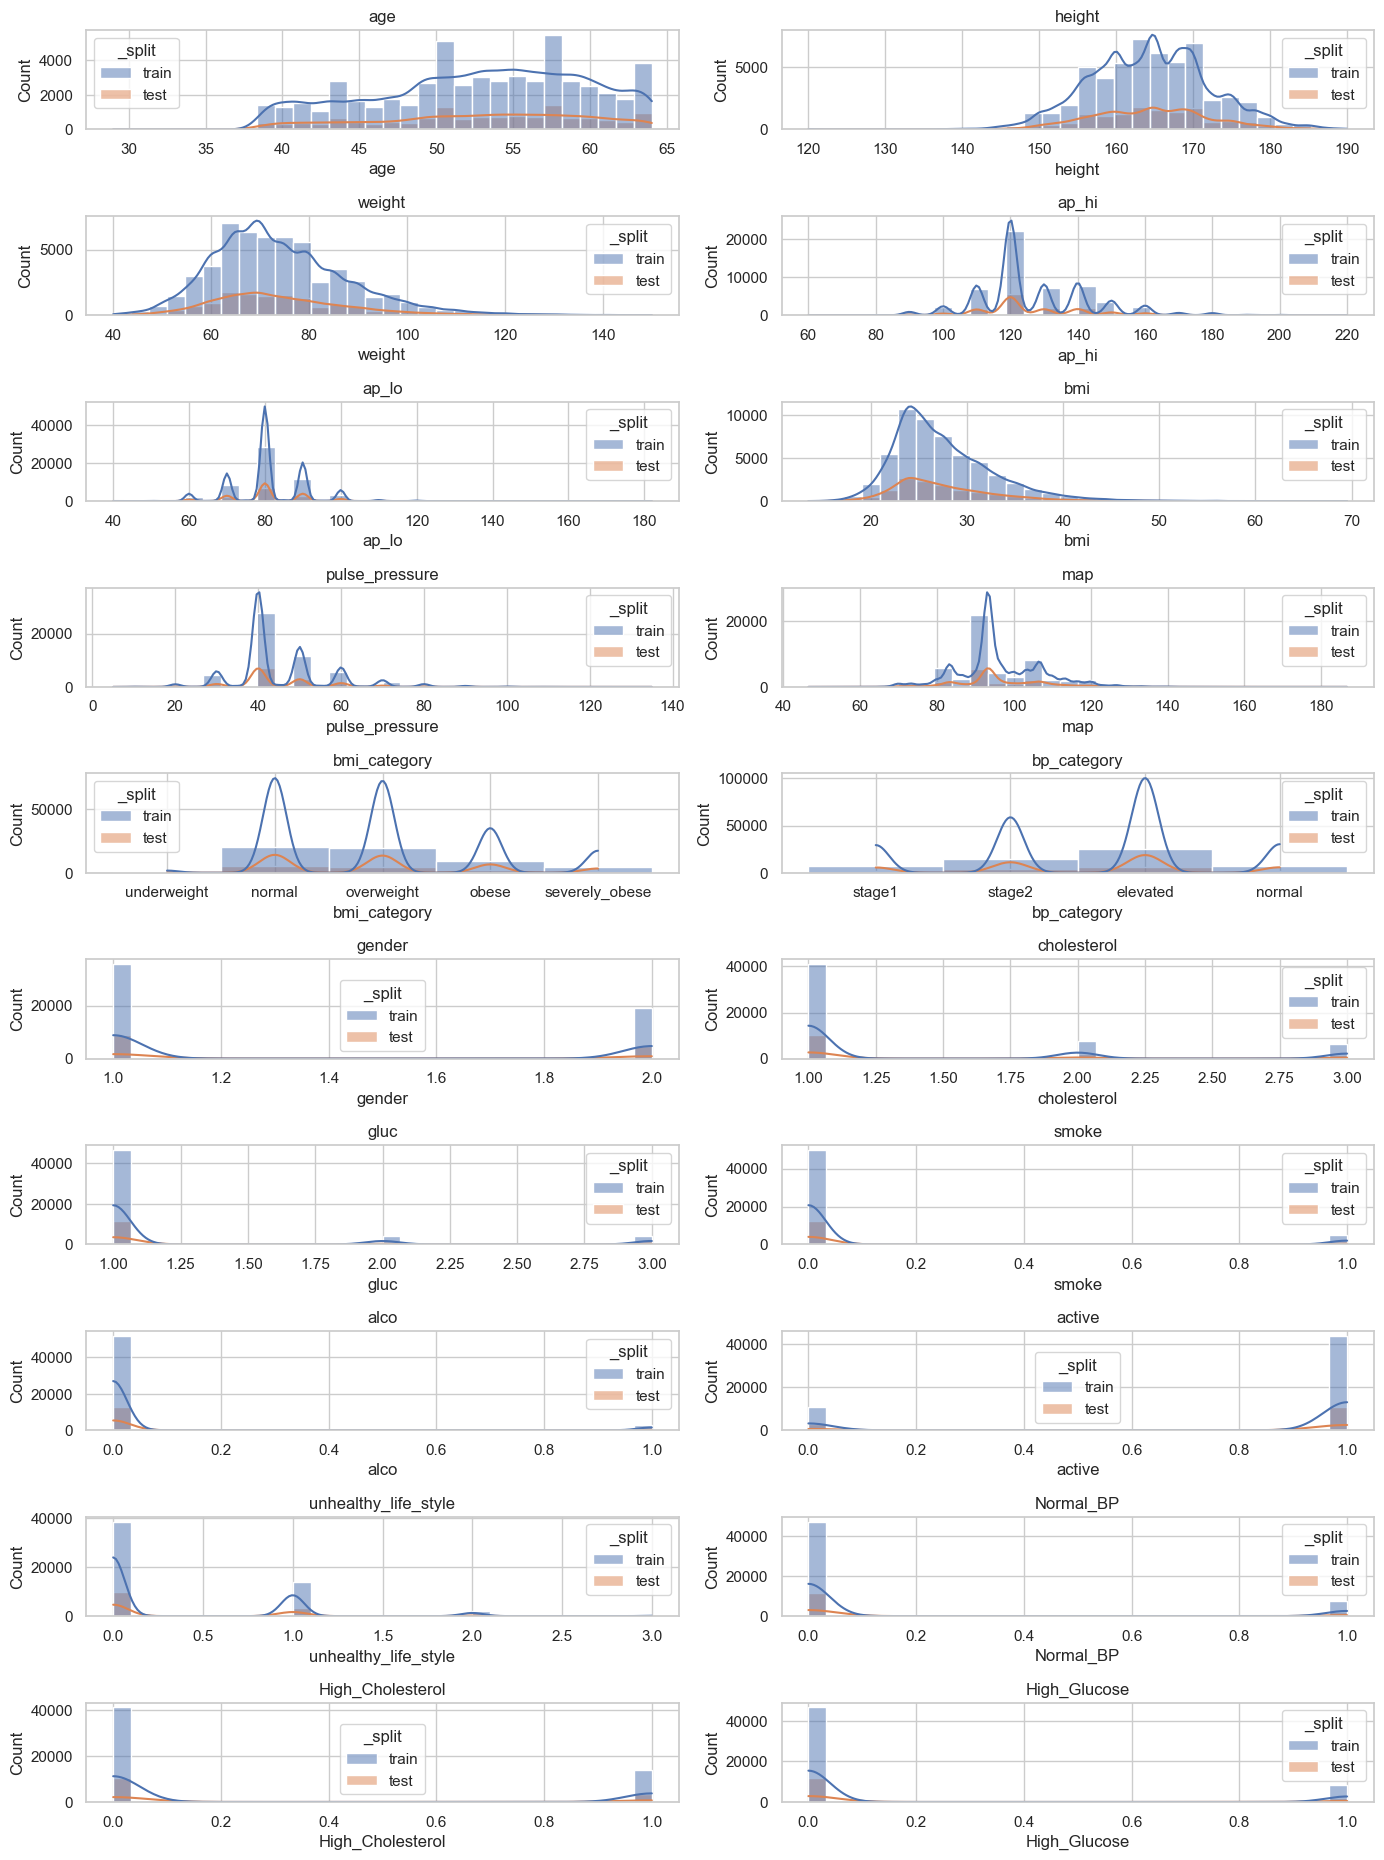

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup the figure subplots
fig, axis = plt.subplots(12, 2, figsize=(14, 22))
axis = axis.flatten()

# 2. Prepare the combined data
train_df = train_df.copy()
test_df = test_df.copy()
train_df['_split'] = 'train'
test_df['_split'] = 'test'
df = pd.concat([train_df, test_df])

# 3. Plot each feature
for i, feature in enumerate(features):
    if feature != 'id':
        # Added hue to actually separate 'train' and 'test' visually on the plot
        sns.histplot(
            data=df,
            x=feature,
            hue='_split',
            kde=True,
            bins=30,
            ax=axis[i],
            multiple="layer"
        )
        # FIXED: Moved inside the loop so every subplot gets its correct title
        axis[i].set_title(feature)

# 4. Clean up any unused empty subplots at the end
for j in range(i + 1, len(axis)):
    fig.delaxes(axis[j])

# 5. Prevent overlapping text and render
plt.tight_layout()
plt.show()

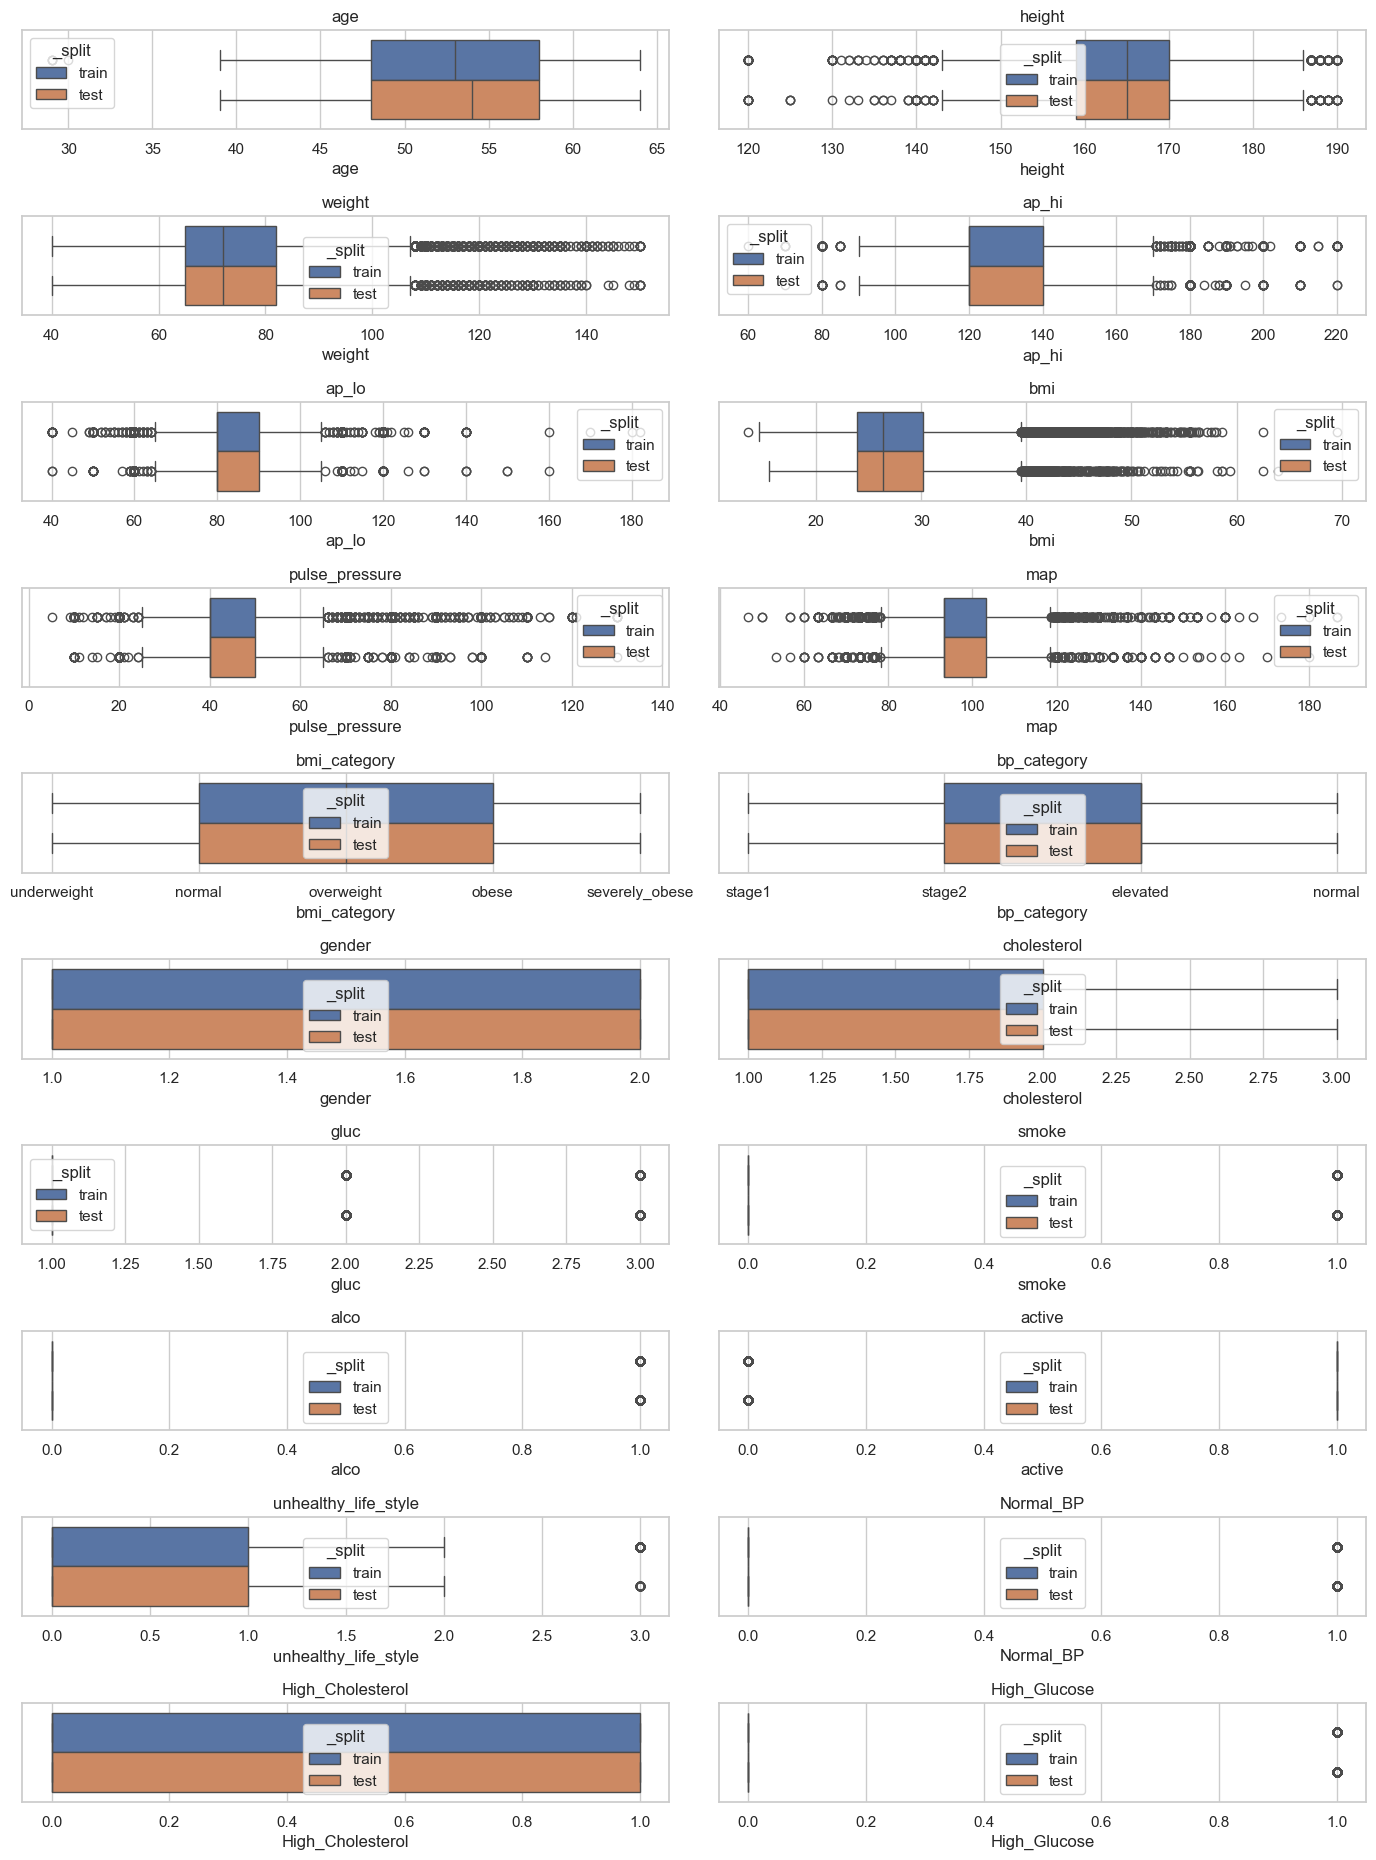

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup the figure subplots
fig, axis = plt.subplots(12, 2, figsize=(14, 22))
axis = axis.flatten()

# 2. Prepare the combined data
train_df = train_df.copy()
test_df = test_df.copy()
train_df['_split'] = 'train'
test_df['_split'] = 'test'
df = pd.concat([train_df, test_df])

# 3. Plot each feature
for i, feature in enumerate(features):
    if feature != 'id':
        # Added hue to actually separate 'train' and 'test' visually on the plot
        sns.boxplot(
            data=df,
            x=feature,
            hue='_split',
            ax=axis[i],
        )
        # FIXED: Moved inside the loop so every subplot gets its correct title
        axis[i].set_title(feature)

# 4. Clean up any unused empty subplots at the end
for j in range(i + 1, len(axis)):
    fig.delaxes(axis[j])

# 5. Prevent overlapping text and render
plt.tight_layout()
plt.show()

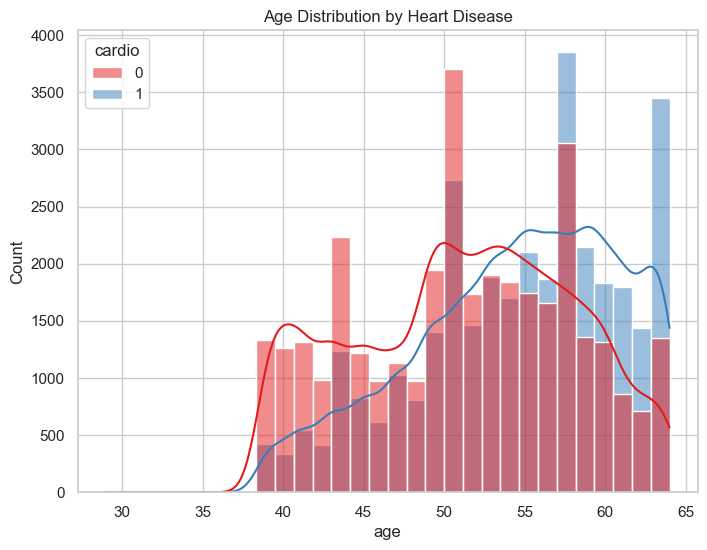

In [54]:
plt.figure(figsize=(8,6))
train_df = train_df.copy()
test_df = test_df.copy()
train_df['_split'] = 'train'
test_df['_split'] = 'test'
df = pd.concat([train_df, test_df])

sns.histplot(
    data=df,
    x="age",
    hue="cardio",
    kde=True,
    bins=30,
    palette="Set1"
)

plt.title("Age Distribution by Heart Disease")

plt.show()

In [55]:
train_df['ap_hi'].max()

np.int64(220)

/var/folders/12/_20q158903d9hmlcjr_qn2z80000gn/T/ipykernel_48402/4003637981.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cardio = (train_df.groupby('age_bins')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')


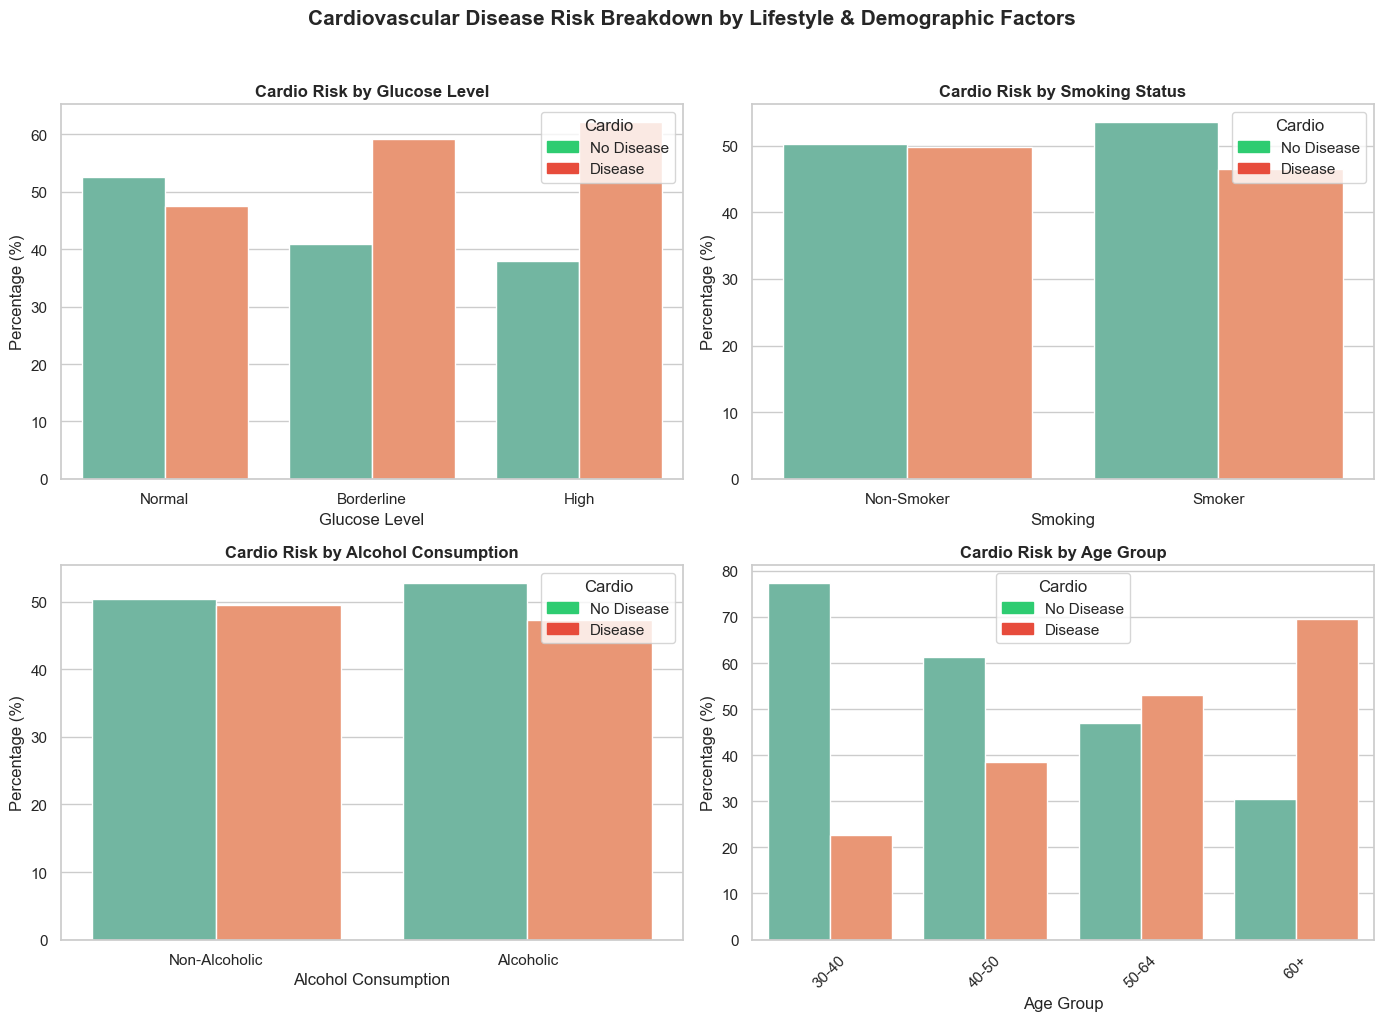

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

sns.set_style('whitegrid')
fig, axis = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axis[0,0], axis[0,1], axis[1,0], axis[1,1]

# Separate dataframes for each plot - don't overwrite the same variable
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='No Disease'),
    mpatches.Patch(color='#e74c3c', label='Disease')
]
glucose_cardio = (train_df.groupby('gluc')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')
smoke_cardio = (train_df.groupby('smoke')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')
alco_cardio = (train_df.groupby('alco')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')
age_cardio = (train_df.groupby('age_bins')['cardio'].value_counts(normalize=True) * 100).reset_index(name='percentage')

# --- Plot 1: Glucose ---
sns.barplot(data=glucose_cardio, x='gluc', y='percentage', hue='cardio', ax=ax1, palette='Set2')
ax1.set_title('Cardio Risk by Glucose Level', fontsize=12, fontweight='bold')
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Normal', 'Borderline', 'High'])
ax1.set_xlabel('Glucose Level')
ax1.set_ylabel('Percentage (%)')
ax1.legend(handles=legend_patches,title='Cardio')

# --- Plot 2: Smoking ---
sns.barplot(data=smoke_cardio, x='smoke', y='percentage', hue='cardio', ax=ax2, palette='Set2')
ax2.set_title('Cardio Risk by Smoking Status', fontsize=12, fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Non-Smoker', 'Smoker'])
ax2.set_xlabel('Smoking')
ax2.set_ylabel('Percentage (%)')
ax2.legend(handles=legend_patches,title='Cardio')

# --- Plot 3: Alcohol ---
sns.barplot(data=alco_cardio, x='alco', y='percentage', hue='cardio', ax=ax3, palette='Set2')
ax3.set_title('Cardio Risk by Alcohol Consumption', fontsize=12, fontweight='bold')
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Non-Alcoholic', 'Alcoholic'])
ax3.set_xlabel('Alcohol Consumption')
ax3.set_ylabel('Percentage (%)')
ax3.legend(handles=legend_patches,title='Cardio')

# --- Plot 4: Age bins ---
sns.barplot(data=age_cardio, x='age_bins', y='percentage', hue='cardio', ax=ax4, palette='Set2')
ax4.set_title('Cardio Risk by Age Group', fontsize=12, fontweight='bold')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Percentage (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(handles=legend_patches,title='Cardio')

fig.suptitle('Cardiovascular Disease Risk Breakdown by Lifestyle & Demographic Factors', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()